# Create Plots Showing Diversity in Heat Wave and Cold Snap Grid Responses


In [1]:
# Start by importing the packages we need:
import os
import warnings
import yaml

import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt


## Suppress Warnings


In [2]:
# Suppress future warnings:
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None


## Set Root Directory

All paths used in this notebook branch off a root directory controlled by a master file `root_directory.yml` stored in the `/notebooks` directory.


In [3]:
# Read the yml file and extract the root directory
with open('root_directory.yml', 'r') as file:
    root_dir = yaml.safe_load(file)
       
# Return the root directory:
root_dir


'/Users/burl878/Documents/Code/code_repos/burleyson-etal_2026_applied_energy'

## Set the Directory Structure

In [4]:
# Set the data input and output directories:
metadata_input_dir = (root_dir + '/data/')
events_data_input_dir = (root_dir + '/data/thermal_events_data/')
image_output_dir = (root_dir + '/figures/regional_results/')


## Plot the Diversity in Thermal Event Weather Characteristics


In [10]:
def plot_hw_cs_events(region: int, hw_cs: str, events_data_input_dir: str, metadata_input_dir: str, image_output_dir: str, image_resolution: int, save_images=False):

    # Read in NERC region name file and extract the TPL-08 region name:
    nerc = pd.read_csv((metadata_input_dir + 'nerc_tpl08_region_names.csv'))
    nerc_name = nerc.loc[nerc['short_name'] == region, 'long_name'].item()
    
    # Extract the heat wave or cold snap library data for a given NERC region:
    if hw_cs == 'HW':
       hw_cs_df = pd.read_csv((events_data_input_dir + 'hw_library_expanded.csv'))
    elif hw_cs == 'CS':
       hw_cs_df = pd.read_csv((events_data_input_dir + 'cs_library_expanded.csv'))

    # Convert the temperatures from F to C:
    hw_cs_df['T_Max_Min_C'] = (hw_cs_df['T_Max_Min']-32)/(9/5)
    
    # Create a year variable and subset to just years 1982-2019 for consistency across all plots:
    hw_cs_df['Center'] = pd.to_datetime(hw_cs_df['Center'])
    hw_cs_df['Year'] = hw_cs_df['Center'].dt.year
    hw_cs_df = hw_cs_df[(hw_cs_df['Year'] >= 1982) & (hw_cs_df['Year'] <= 2019)].copy()
    
    # Subset to just the data for region you want to use:
    subset_df = hw_cs_df[(hw_cs_df['Region'] == region)].copy()
    
    # Bin the regions impacted values and scale them for the scatter plot:
    subset_df['Regions_Impacted_Normalized'] = 0
    subset_df['Regions_Impacted_Normalized'].loc[(subset_df['Regions_Impacted'] == 1)] = 25
    subset_df['Regions_Impacted_Normalized'].loc[(subset_df['Regions_Impacted'] == 2)] = 75
    subset_df['Regions_Impacted_Normalized'].loc[(subset_df['Regions_Impacted'] == 3)] = 175
    subset_df['Regions_Impacted_Normalized'].loc[(subset_df['Regions_Impacted'] == 4)] = 325
    subset_df['Regions_Impacted_Normalized'].loc[(subset_df['Regions_Impacted'] == 5)] = 525
    subset_df['Regions_Impacted_Normalized'].loc[(subset_df['Regions_Impacted'] >= 6)] = 775
    
    # Set the rankings by temperature:
    if hw_cs == 'HW':
       subset_df = subset_df.sort_values('T_Max_Min', ascending=False)
       subset_df['T_Rank'] = range(len(subset_df))
       subset_df['T_Rank'] = subset_df['T_Rank'] + 1
    if hw_cs == 'CS':
       subset_df = subset_df.sort_values('T_Max_Min')
       subset_df['T_Rank'] = range(len(subset_df))
       subset_df['T_Rank'] = subset_df['T_Rank'] + 1    

    # Sort by date and reset the index:
    subset_df = subset_df.sort_values('Start')
    subset_df.reset_index(inplace=True, drop=True)
    
    # For cold snaps, shift the centroid date to plot whole winter seasons together:
    if hw_cs == 'CS':
       subset_df.loc[(subset_df['Center_DOY'] > 182), 'Center_DOY'] = subset_df['Center_DOY']-365

    # Set the plot parameters based on plotting heat waves or cold snaps:
    if hw_cs == 'HW':
       cmap = plt.get_cmap('Reds', 21)
       xticks = [121, 152, 182, 213, 244, 274]
       xticklabels = ['May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']
       xmin = 121
       xmax = 274 
       scale_color = 'r'
       ylabel = 'Maximum Temperature [$^\circ$C]'
       title = ('Heat Wave Events in ' + nerc_name + '\n 1982-2019, N=' + str(len(subset_df)))
    elif hw_cs == 'CS':
       cmap = plt.get_cmap('Blues', 21)
       xticks = [-61, -31, 1, 32, 60, 91]
       xticklabels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']
       xmin = -61
       xmax = 91  
       scale_color = 'b'
       ylabel = 'Minimum Temperature [$^\circ$C]'
       title = ('Cold Snap Events in ' + nerc_name + '\n 1982-2019, N=' + str(len(subset_df)))

    # Identify the top-40 events based on the maximum or minimum event temperature:
    top40_events_df = subset_df.loc[(subset_df['T_Rank'] <= 20)].copy()
    nottop40_events_df = subset_df.loc[(subset_df['T_Rank'] > 20)].copy()
    
    # Make the scatter plot:
    plt.figure(figsize=(20, 10))
    plt.rcParams['font.size'] = 20
    plt.rcParams['axes.axisbelow'] = True
    sc = plt.scatter(nottop40_events_df['Center_DOY'], nottop40_events_df['T_Max_Min_C'], s=(nottop40_events_df['Regions_Impacted_Normalized']), c=nottop40_events_df['Duration'], 
                     edgecolors='k', linestyle='--', cmap=cmap, vmin=0, vmax=21)
    top40sc = plt.scatter(top40_events_df['Center_DOY'], top40_events_df['T_Max_Min_C'], s=(top40_events_df['Regions_Impacted_Normalized']), c=top40_events_df['Duration'], 
                          edgecolors='k', linestyle='-', cmap=cmap, vmin=0, vmax=21)
    plt.scatter(-100,-100,s=25, c=scale_color, label='N=1 Region')
    plt.scatter(-100,-100,s=75, c=scale_color, label='N=2 Regions')
    plt.scatter(-100,-100,s=175, c=scale_color, label='N=3 Regions')
    plt.scatter(-100,-100,s=325, c=scale_color, label='N=4 Regions')
    plt.scatter(-100,-100,s=525, c=scale_color, label='N=5 Regions')
    plt.scatter(-100,-100,s=775, c=scale_color, label=(r'N$\geq$6 Regions'))
    cbar = plt.colorbar(sc, ticks=[0, 7, 14, 21])
    cbar.ax.set_ylabel('Event Duration [Days]')
    plt.legend(loc='best', prop={'size': 20})
    plt.grid()
    plt.xticks(xticks, xticklabels)
    plt.xlim([xmin, xmax])
    plt.ylim([(subset_df['T_Max_Min_C'].min()-0.5), (subset_df['T_Max_Min_C'].max()+0.5)])
    plt.ylabel(ylabel)
    plt.title(title)

    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       plt.savefig(os.path.join(image_output_dir + str(region) + '_' + hw_cs + '_Events.png'), dpi=image_resolution, bbox_inches='tight')
       plt.close()


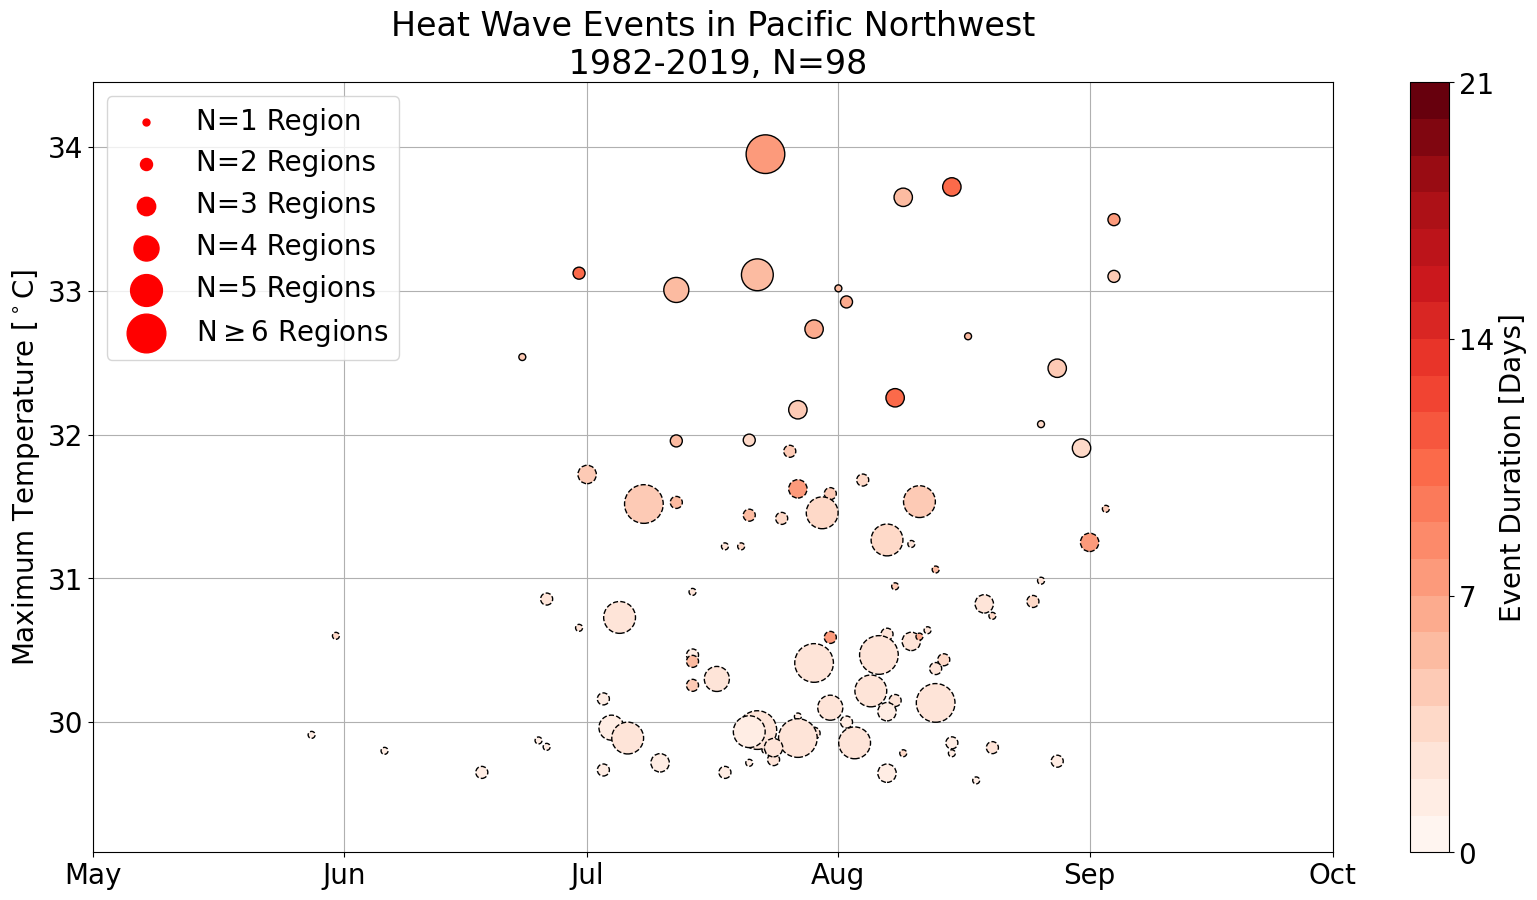

In [13]:
# Test the function:
plot_hw_cs_events(region = 'PNW',
                  hw_cs = 'HW',
                  events_data_input_dir = events_data_input_dir,
                  metadata_input_dir = metadata_input_dir,
                  image_output_dir = image_output_dir, 
                  image_resolution = 150,
                  save_images = False)


In [14]:
# Loop over the NERC TPL-008-1 regions and make the plot for each region:
for region in ['CA', 'ERCOT', 'FL', 'GB', 'ISONE', 'MISO-N', 'MISO-S', 'NYISO', 'PJM', 'PNW', 'RM', 'SERC', 'SPP-N', 'SPP-S', 'SW']:

    # Loop over heat wave and cold snap event types:
    for event_type in ['HW', 'CS']:
    
        # Make the plot:
        plot_hw_cs_events(region = region,
                          hw_cs = event_type,
                          events_data_input_dir = events_data_input_dir,
                          metadata_input_dir = metadata_input_dir,
                          image_output_dir = image_output_dir, 
                          image_resolution = 150,
                          save_images = True)


## Plot the Diversity in Thermal Event Weather and Load Characteristics

Note that this will only work for NERC TPL-008-1 regions in the WECC because they're the only ones with the requisite load data.


In [ ]:
def plot_hw_cs_histograms(region: int, hw_cs: str, events_data_input_dir: str, metadata_input_dir: str, image_output_dir: str, image_resolution: int, save_images=False):

    # Read in NERC region name file and extract the TPL-08 region name:
    nerc = pd.read_csv((metadata_input_dir + 'nerc_tpl08_region_names.csv'))
    nerc_name = nerc.loc[nerc['short_name'] == region, 'long_name'].item()
       
    # Extract the heat wave or cold snap library data for a given NERC region:
    if hw_cs == 'HW':
       hw_cs_df = pd.read_csv((events_data_input_dir + 'hw_library_expanded.csv'))
    elif hw_cs == 'CS':
       hw_cs_df = pd.read_csv((events_data_input_dir + 'cs_library_expanded.csv'))

    # Create a year variable and subset to just years 1982-2019 for consistency across all plots:
    hw_cs_df['Center'] = pd.to_datetime(hw_cs_df['Center'])
    hw_cs_df['Year'] = hw_cs_df['Center'].dt.year
    hw_cs_df = hw_cs_df[(hw_cs_df['Year'] >= 1982) & (hw_cs_df['Year'] <= 2019)].copy()
    
    # Subset to just the data for region you want to use:
    subset_df = hw_cs_df[(hw_cs_df['Region'] == region)].copy()

    # Drop rows containing NaN import values (i.e., no GridView results):
    subset_df.dropna(subset=['Import_at_Peak'], inplace=True)
    
    # Set the rankings by temperature:
    if hw_cs == 'HW':
       subset_df = subset_df.sort_values('T_Max_Min', ascending=False)
       subset_df['T_Rank'] = range(len(subset_df))
       subset_df['T_Rank'] = subset_df['T_Rank'] + 1
    if hw_cs == 'CS':
       subset_df = subset_df.sort_values('T_Max_Min')
       subset_df['T_Rank'] = range(len(subset_df))
       subset_df['T_Rank'] = subset_df['T_Rank'] + 1    

    # Sort by date and reset the index:
    subset_df = subset_df.sort_values('Start')
    subset_df.reset_index(inplace=True, drop=True)

    # Convert the demands from MW to GW:
    subset_df['Region_Load_Peak'] = subset_df['Region_Load_Peak']/1000
    subset_df['WECC_Load_Peak'] = subset_df['WECC_Load_Peak']/1000
    subset_df['Import_at_Peak'] = subset_df['Import_at_Peak']/1000
    subset_df['Total_at_Peak'] = subset_df['Total_at_Peak']/1000
    subset_df['Renew_at_Peak'] = subset_df['Renew_at_Peak']*100
    
    # Identify the top-40 events based on the maximum or minimum event temperature:
    top40_events_df = subset_df.loc[(subset_df['T_Rank'] <= 20)].copy()
   
    # Create the bins:
    region_load_bins = np.arange(subset_df['Region_Load_Peak'].min(), subset_df['Region_Load_Peak'].max(), ((subset_df['Region_Load_Peak'].max() - subset_df['Region_Load_Peak'].min()) / 20))
    wecc_load_bins = np.arange(subset_df['WECC_Load_Peak'].min(), subset_df['WECC_Load_Peak'].max(), ((subset_df['WECC_Load_Peak'].max() - subset_df['WECC_Load_Peak'].min()) / 20))
    import_bins = np.arange(subset_df['Import_at_Peak'].min(), subset_df['Import_at_Peak'].max(), ((subset_df['Import_at_Peak'].max() - subset_df['Import_at_Peak'].min()) / 20))
    gen_bins = np.arange(subset_df['Total_at_Peak'].min(), subset_df['Total_at_Peak'].max(), ((subset_df['Total_at_Peak'].max() - subset_df['Total_at_Peak'].min()) / 20))
    renew_bins = np.arange(subset_df['Renew_at_Peak'].min(), subset_df['Renew_at_Peak'].max(), ((subset_df['Renew_at_Peak'].max() - subset_df['Renew_at_Peak'].min()) / 20))
    if subset_df['Max_Load_Shed'].max() != 0:
       shed_bins = np.arange(subset_df['Max_Load_Shed'].min(), subset_df['Max_Load_Shed'].max(), ((subset_df['Max_Load_Shed'].max() - subset_df['Max_Load_Shed'].min()) / 20))
    else:
       shed_bins = np.arange(0, 10, 0.5)
    
    # Make the histogram plot:
    plt.figure(figsize=(25, 20))
    plt.rcParams['font.size'] = 20
    plt.rcParams['axes.axisbelow'] = True

    plt.subplot(231)
    plt.hist(subset_df['Region_Load_Peak'], bins=region_load_bins, density=False, histtype='stepfilled', facecolor='gray', alpha=.5)
    plt.hist(top40_events_df['Region_Load_Peak'], bins=region_load_bins, density=False, histtype='step', color='r', linewidth=3)
    #plt.hist(subset_df['Region_Load_Peak'], bins=region_load_bins, density=True, histtype='stepfilled', facecolor='gray', alpha=.5)
    #plt.hist(top40_events_df['Region_Load_Peak'], bins=region_load_bins, density=True, histtype='step', color='r', linewidth=3)
    plt.xlabel('Event Regional Peak Demand [GW]') 
    plt.ylabel('Count')
    #plt.ylabel('Probability Density')
    plt.title('a)', loc='left', fontsize=20)
    plt.title(('Regional Peak Demand'))
    
    plt.subplot(232)
    plt.hist(subset_df['WECC_Load_Peak'], bins=wecc_load_bins, density=False, histtype='stepfilled', facecolor='gray', alpha=.5)
    plt.hist(top40_events_df['WECC_Load_Peak'], bins=wecc_load_bins, density=False, histtype='step', color='r', linewidth=3)
    #plt.hist(subset_df['WECC_Load_Peak'], bins=wecc_load_bins, density=True, histtype='stepfilled', facecolor='gray', alpha=.5)
    #plt.hist(top40_events_df['WECC_Load_Peak'], bins=wecc_load_bins, density=True, histtype='step', color='r', linewidth=3)
    plt.xlabel('Event Interconnection Peak Demand [GW]') 
    plt.ylabel('Count')
    #plt.ylabel('Probability Density')
    plt.title('b)', loc='left', fontsize=20)
    plt.title('Interconnection Peak Demand')

    plt.subplot(233)
    plt.hist(subset_df['Import_at_Peak'], bins=import_bins, density=False, histtype='stepfilled', facecolor='gray', alpha=.5)
    plt.hist(top40_events_df['Import_at_Peak'], bins=import_bins, density=False, histtype='step', color='r', linewidth=3)
    #plt.hist(subset_df['Import_at_Peak'], bins=import_bins, density=True, histtype='stepfilled', facecolor='gray', alpha=.5)
    #plt.hist(top40_events_df['Import_at_Peak'], bins=import_bins, density=True, histtype='step', color='r', linewidth=3)
    plt.xlabel('Imports at Time of Peak [GW]') 
    plt.ylabel('Count')
    #plt.ylabel('Probability Density')
    plt.title('c)', loc='left', fontsize=20)
    plt.title('Regional Imports')

    plt.subplot(234)
    plt.hist(subset_df['Total_at_Peak'], bins=gen_bins, density=False, histtype='stepfilled', facecolor='gray', alpha=.5)
    plt.hist(top40_events_df['Total_at_Peak'], bins=gen_bins, density=False, histtype='step', color='r', linewidth=3)
    #plt.hist(subset_df['Total_at_Peak'], bins=gen_bins, density=True, histtype='stepfilled', facecolor='gray', alpha=.5)
    #plt.hist(top40_events_df['Total_at_Peak'], bins=gen_bins, density=True, histtype='step', color='r', linewidth=3)
    plt.xlabel('Generation at Time of Peak [GW]') 
    plt.ylabel('Count')
    #plt.ylabel('Probability Density')
    plt.title('d)', loc='left', fontsize=20)
    plt.title('Regional Generation')

    plt.subplot(235)
    plt.hist(subset_df['Renew_at_Peak'], bins=renew_bins, density=False, histtype='stepfilled', facecolor='gray', alpha=.5)
    plt.hist(top40_events_df['Renew_at_Peak'], bins=renew_bins, density=False, histtype='step', color='r', linewidth=3)
    #plt.hist(subset_df['Renew_at_Peak'], bins=renew_bins, density=True, histtype='stepfilled', facecolor='gray', alpha=.5)
    #plt.hist(top40_events_df['Renew_at_Peak'], bins=renew_bins, density=True, histtype='step', color='r', linewidth=3)
    plt.xlabel('Renewables Contribution at Time of Peak [%]') 
    plt.ylabel('Count')
    #plt.ylabel('Probability Density')
    plt.title('e)', loc='left', fontsize=20)
    plt.title('Regional Renewables')

    plt.subplot(236)
    plt.hist(subset_df['Max_Load_Shed'], bins=shed_bins, density=False, histtype='stepfilled', facecolor='gray', alpha=.5)
    plt.hist(top40_events_df['Max_Load_Shed'], bins=shed_bins, density=False, histtype='step', color='r', linewidth=3)
    #plt.hist(subset_df['Max_Load_Shed'], bins=shed_bins, density=True, histtype='stepfilled', facecolor='gray', alpha=.5)
    #plt.hist(top40_events_df['Max_Load_Shed'], bins=shed_bins, density=True, histtype='step', color='r', linewidth=3)
    plt.xlabel('Event Maximum Load Shed [MW]') 
    plt.ylabel('Count')
    #plt.ylabel('Probability Density')
    plt.title('f)', loc='left', fontsize=20)
    plt.title('Regional Load Shedding')

    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       plt.savefig(os.path.join(image_output_dir + str(region) + '_' + hw_cs + '_Histograms.png'), dpi=image_resolution, bbox_inches='tight')
       #plt.savefig(os.path.join(image_output_dir + str(region) + '_' + hw_cs + '_Histograms_Normalize.png'), dpi=image_resolution, bbox_inches='tight')
       plt.close()


In [ ]:
# Test the function:
plot_hw_cs_histograms(region = 'GB',
                      hw_cs = 'HW',
                      events_data_input_dir = events_data_input_dir,
                      metadata_input_dir = metadata_input_dir,
                      image_output_dir = image_output_dir, 
                      image_resolution = 150,
                      save_images = False)


In [ ]:
# Loop over the NERC TPL-008-1 regions in the WECC and make the plot for each region:
for region in ['CA', 'GB', 'PNW', 'RM', 'SW']:

    # Loop over heat wave and cold snap event types:
    for event_type in ['HW', 'CS']:
    
        # Make the plot:
        plot_hw_cs_histograms(region = region,
                              hw_cs = event_type,
                              events_data_input_dir = events_data_input_dir,
                              metadata_input_dir = metadata_input_dir,
                              image_output_dir = image_output_dir, 
                              image_resolution = 150,
                              save_images = True)


## Plot the Rankings of Events Based on Different Variables

Note that this will only work for NERC TPL-008-1 regions in the WECC because they're the only ones with the requisite load data.

In [ ]:
def plot_hw_cs_rankings(region: int, hw_cs: str, events_data_input_dir: str, metadata_input_dir: str, image_output_dir: str, image_resolution: int, save_images=False):

    # Read in NERC region name file and extract the TPL-08 region name:
    nerc = pd.read_csv((metadata_input_dir + 'nerc_tpl08_region_names.csv'))
    nerc_name = nerc.loc[nerc['short_name'] == region, 'long_name'].item()
       
    # Extract the heat wave or cold snap library data for a given NERC region:
    if hw_cs == 'HW':
       hw_cs_df = pd.read_csv((events_data_input_dir + 'hw_library_expanded.csv'))
    elif hw_cs == 'CS':
       hw_cs_df = pd.read_csv((events_data_input_dir + 'cs_library_expanded.csv'))

    # Create a year variable and subset to just years 1982-2019 for consistency across all plots:
    hw_cs_df['Center'] = pd.to_datetime(hw_cs_df['Center'])
    hw_cs_df['Year'] = hw_cs_df['Center'].dt.year
    hw_cs_df = hw_cs_df[(hw_cs_df['Year'] >= 1982) & (hw_cs_df['Year'] <= 2019)].copy()
    
    # Subset to just the data for region you want to use:
    subset_df = hw_cs_df[(hw_cs_df['Region'] == region)].copy()

    # Drop rows containing NaN import values (i.e., no GridView results):
    subset_df.dropna(subset=['Import_at_Peak'], inplace=True)
    
    # Set the rankings by temperature:
    if hw_cs == 'HW':
       subset_df = subset_df.sort_values('T_Max_Min', ascending=False)
       subset_df['T_Rank'] = range(len(subset_df))
       subset_df['T_Rank'] = subset_df['T_Rank'] + 1
    if hw_cs == 'CS':
       subset_df = subset_df.sort_values('T_Max_Min')
       subset_df['T_Rank'] = range(len(subset_df))
       subset_df['T_Rank'] = subset_df['T_Rank'] + 1    

    # Set the rankings by WECC load peak:
    subset_df = subset_df.sort_values('WECC_Load_Peak', ascending=False)
    subset_df['WECC_Peak_Rank'] = range(len(subset_df))
    subset_df['WECC_Peak_Rank'] = subset_df['WECC_Peak_Rank'] + 1

    # Set the rankings by regional load peak:
    subset_df = subset_df.sort_values('Region_Load_Peak', ascending=False)
    subset_df['Region_Peak_Rank'] = range(len(subset_df))
    subset_df['Region_Peak_Rank'] = subset_df['Region_Peak_Rank'] + 1

    # Set the rankings by imports at time of peak demand:
    subset_df = subset_df.sort_values('Import_at_Peak', ascending=False)
    subset_df['Imports_Rank'] = range(len(subset_df))
    subset_df['Imports_Rank'] = subset_df['Imports_Rank'] + 1
    subset_df.loc[subset_df['Import_at_Peak'].isna(), 'Imports_Rank'] = np.nan

    # Set the rankings by renewables contribution at time of peak demand:
    subset_df = subset_df.sort_values('Renew_at_Peak', ascending=False)
    subset_df['Renewables_Rank'] = range(len(subset_df))
    subset_df['Renewables_Rank'] = subset_df['Renewables_Rank'] + 1
    subset_df.loc[subset_df['Renew_at_Peak'].isna(), 'Renewables_Rank'] = np.nan

    # Set the rankings by maximum load shed:
    subset_df = subset_df.sort_values('Max_Load_Shed', ascending=False)
    subset_df['Load_Shed_Rank'] = range(len(subset_df))
    subset_df['Load_Shed_Rank'] = subset_df['Load_Shed_Rank'] + 1
    subset_df.loc[(subset_df['Max_Load_Shed'] == 0), 'Load_Shed_Rank'] = np.nan
    
    # Sort by date and reset the index:
    subset_df = subset_df.sort_values('Start')
    subset_df.reset_index(inplace=True, drop=True)

    # Identify the top-40 events based on the maximum or minimum event temperature:
    top20_events_df = subset_df.loc[(subset_df['T_Rank'] <= 20)].copy()

    # Create a 1:1 line for plotting:
    one_to_one = np.arange(0, 300, 10)
    ticks = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200]
    ticklabels = ['0','','20','','40','','60','','80','','100','','120','','140','','160','','180','','200']

    # Set the dot color for heat waves and cold snaps:
    if hw_cs == 'HW':
       dot_color = 'r'
    else:
       dot_color = 'b'

    xmax1 = top20_events_df['T_Rank'].max()
    ymax1 = top20_events_df['Region_Peak_Rank'].max()
    xmax2 = top20_events_df['T_Rank'].max()
    ymax2 = top20_events_df['Load_Shed_Rank'].max()
    xmax3 = top20_events_df['Region_Peak_Rank'].max()
    ymax3 = top20_events_df['WECC_Peak_Rank'].max()
    xmax4 = top20_events_df['Region_Peak_Rank'].max()
    ymax4 = top20_events_df['Imports_Rank'].max()
    
    # Make the scatter plot:
    plt.figure(figsize=(25, 25))
    plt.rcParams['font.size'] = 21
    plt.rcParams['axes.axisbelow'] = True

    plt.subplot(221)
    plt.fill([0, xmax1, xmax1, 0], [0, 0, ymax1, ymax1], 'gray', zorder=1, alpha=0.2)
    plt.plot(one_to_one,one_to_one, 'gray', linewidth=2, zorder=2)
    plt.scatter(subset_df['T_Rank'], subset_df['Region_Peak_Rank'], s=100, c='k', label=('Correlation=' + str(subset_df['T_Rank'].corr(subset_df['Region_Peak_Rank'], method='spearman').round(2))), zorder=3)
    plt.scatter(top20_events_df['T_Rank'], top20_events_df['Region_Peak_Rank'], s=100, c=dot_color, label=('Correlation=' + str(top20_events_df['T_Rank'].corr(top20_events_df['Region_Peak_Rank'], method='spearman').round(2))), zorder=4)
    plt.xticks(ticks, ticklabels)
    plt.xlim(0, len(subset_df)+3)
    plt.ylim(0, len(subset_df)+3)
    plt.legend(loc='upper left', fontsize=24, facecolor='white', framealpha=1)
    plt.xlabel('Temperature Rank', fontsize=27) 
    plt.ylabel('Region Peak Demand Rank', fontsize=27)
    plt.title('a)', loc='left', fontsize=24)
    plt.title('Temperature vs Region Peak Demand', fontsize=29)

    plt.subplot(222)
    plt.fill([0, xmax2, xmax2, 0], [0, 0, ymax2, ymax2], 'gray', zorder=1, alpha=0.2)
    plt.plot(one_to_one,one_to_one, 'gray', linewidth=2, zorder=2)
    if subset_df['Load_Shed_Rank'].isna().all() == False:
       plt.scatter(subset_df['T_Rank'], subset_df['Load_Shed_Rank'], s=100, c='k', label=('Correlation=' + str(subset_df['T_Rank'].corr(subset_df['Load_Shed_Rank'], method='spearman').round(2))), zorder=3)
       plt.scatter(top20_events_df['T_Rank'], top20_events_df['Load_Shed_Rank'], s=100, c=dot_color, label=('Correlation=' + str(top20_events_df['T_Rank'].corr(top20_events_df['Load_Shed_Rank'], method='spearman').round(2))), zorder=4)
    plt.xticks(ticks, ticklabels)
    plt.xlim(0, len(subset_df)+3)
    plt.ylim(0, len(subset_df)+3)
    plt.legend(loc='upper left', fontsize=24, facecolor='white', framealpha=1)
    plt.xlabel('Temperature Rank', fontsize=27) 
    plt.ylabel('Maximum Load Shed Rank', fontsize=27)
    plt.title('b)', loc='left', fontsize=24)
    plt.title('Temperature vs Load Shed', fontsize=29)

    plt.subplot(223)
    plt.fill([0, xmax3, xmax3, 0], [0, 0, ymax3, ymax3], 'gray', zorder=1, alpha=0.2)
    plt.plot(one_to_one,one_to_one,'gray', linewidth=2, zorder=2)
    plt.scatter(subset_df['Region_Peak_Rank'], subset_df['WECC_Peak_Rank'], s=100, c='k', label=('Correlation=' + str(subset_df['Region_Peak_Rank'].corr(subset_df['WECC_Peak_Rank'], method='spearman').round(2))), zorder=3)
    plt.scatter(top20_events_df['Region_Peak_Rank'], top20_events_df['WECC_Peak_Rank'], s=100, c=dot_color, label=('Correlation=' + str(top20_events_df['Region_Peak_Rank'].corr(top20_events_df['WECC_Peak_Rank'], method='spearman').round(2))), zorder=4)
    plt.xticks(ticks, ticklabels)
    plt.xlim(0, len(subset_df)+3)
    plt.ylim(0, len(subset_df)+3)
    plt.legend(loc='upper left', fontsize=24, facecolor='white', framealpha=1)
    plt.xlabel('Region Peak Demand Rank', fontsize=27) 
    plt.ylabel('Interconnection Peak Demand Rank', fontsize=27)
    plt.title('c)', loc='left', fontsize=24)
    plt.title('Region vs Interconnection Peak Demand', fontsize=29)

    plt.subplot(224)
    plt.fill([0, xmax4, xmax4, 0], [0, 0, ymax4, ymax4], 'gray', zorder=1, alpha=0.2)
    plt.plot(one_to_one,one_to_one,'gray', linewidth=2, zorder=2)
    plt.scatter(subset_df['Region_Peak_Rank'], subset_df['Imports_Rank'], s=100, c='k', label=('Correlation=' + str(subset_df['Region_Peak_Rank'].corr(subset_df['Imports_Rank'], method='spearman').round(2))), zorder=3)
    plt.scatter(top20_events_df['Region_Peak_Rank'], top20_events_df['Imports_Rank'], s=100, c=dot_color, label=('Correlation=' + str(top20_events_df['Region_Peak_Rank'].corr(top20_events_df['Imports_Rank'], method='spearman').round(2))), zorder=4)
    plt.xticks(ticks, ticklabels)
    plt.xlim(0, len(subset_df)+3)
    plt.ylim(0, len(subset_df)+3)
    plt.legend(loc='upper left', fontsize=24, facecolor='white', framealpha=1)
    plt.xlabel('Region Peak Demand Rank', fontsize=27) 
    plt.ylabel('Imports at Time of Peak Demand Rank', fontsize=27)
    plt.title('d)', loc='left', fontsize=24)
    plt.title('Region Peak Demand vs Imports', fontsize=29)

    # If the "save_images" flag is set to true then save the plot to a .png file:
    if save_images == True:
       plt.savefig(os.path.join(image_output_dir + str(region) + '_' + hw_cs + '_Rankings.png'), dpi=image_resolution, bbox_inches='tight')
       plt.close()

    # Return the dataframe so the rankings for the case studies can be extracted:
    return subset_df


In [ ]:
# Test the function:
output_df = plot_hw_cs_rankings(region = 'PNW',
                                hw_cs = 'HW',
                                events_data_input_dir = events_data_input_dir,
                                metadata_input_dir = metadata_input_dir,
                                image_output_dir = image_output_dir, 
                                image_resolution = 150,
                                save_images = False)

output_df


In [ ]:
# Loop over the NERC TPL-008-1 regions in the WECC and make the plot for each region:
for region in ['CA', 'GB', 'PNW', 'RM', 'SW']:

    # Loop over heat wave and cold snap event types:
    for event_type in ['HW', 'CS']:

        # Make the plot:
        plot_hw_cs_rankings(region = region,
                            hw_cs = event_type,
                            events_data_input_dir = events_data_input_dir,
                            metadata_input_dir = metadata_input_dir,
                            image_output_dir = image_output_dir, 
                            image_resolution = 150,
                            save_images = True)
